<a href="https://colab.research.google.com/github/DiliniSew/Deep-Learning_Mini-Project/blob/Ganindu_Dev/Copy_of_Notebook_gdesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Loading

In [ ]:
!pip install opendatasets

In [ ]:
from keras.preprocessing.image import load_img
import opendatasets as od
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import Dropout, Input, Add, Dense, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model, load_model

In [ ]:

od.download("https://www.kaggle.com/datasets/jangedoo/utkface-new?datasetId=44109")
#{"username":"rpddsewwandi","key":"d0fb60c60bae0d7a83861a898162a399"}

Skipping, found downloaded files in "./utkface-new" (use force=True to force download)


In [ ]:

# Removed 'import random' as shuffling is no longer required

data_path = "/content/utkface-new/utkface_aligned_cropped/UTKFace"

image_paths = []
age_labels = []
gender_labels = []

if os.path.exists(data_path):
    print(f"Processing files in '{data_path}'...")
    for item in os.listdir(data_path):
        if item.endswith(".jpg") or item.endswith(".png"):
            # Filename format: age_gender_ethnicity_date.jpg.chip.jpg
            parts = item.split('_')
            if len(parts) >= 2:
                try:
                    age = int(parts[0])
                    gender = int(parts[1])
                    image_paths.append(os.path.join(data_path, item))
                    age_labels.append(age)
                    gender_labels.append(gender)
                except ValueError:
                    # Skip files with unparseable age/gender
                    continue

    print(f"Found {len(image_paths)} images.")

    # Create a DataFrame
    data = pd.DataFrame({
        'image': image_paths,
        'age': age_labels,
        'gender': gender_labels
    })

else:
    print(f"Error: Directory '{data_path}' does not exist.")


Processing files in '/content/utkface-new/utkface_aligned_cropped/UTKFace'...
Found 23708 images.


In [ ]:
print("\nFirst 5 entries of the DataFrame:")
data.head()


First 5 entries of the DataFrame:


,image,age,gender
0,/content/utkface-new/utkface_aligned_cropped/U...,24,0
1,/content/utkface-new/utkface_aligned_cropped/U...,40,1
2,/content/utkface-new/utkface_aligned_cropped/U...,38,1
3,/content/utkface-new/utkface_aligned_cropped/U...,58,1
4,/content/utkface-new/utkface_aligned_cropped/U...,48,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   23708 non-null  object
 1   age     23708 non-null  int64 
 2   gender  23708 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


[Text(0.5, 1.0, 'Distribution of Age')]

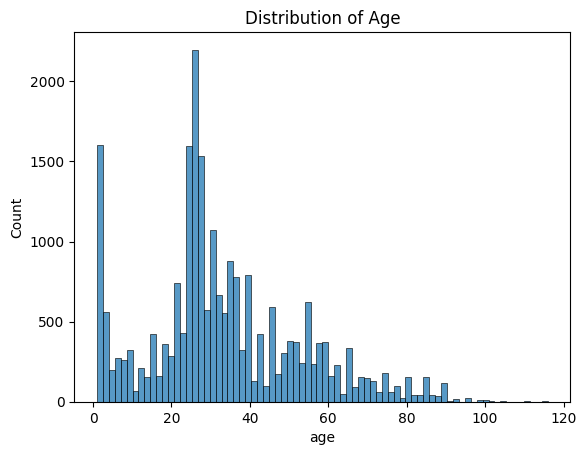

In [ ]:
sns.histplot(data.age).set(title="Distribution of Age")

[Text(0.5, 1.0, 'Distribution of Gender')]

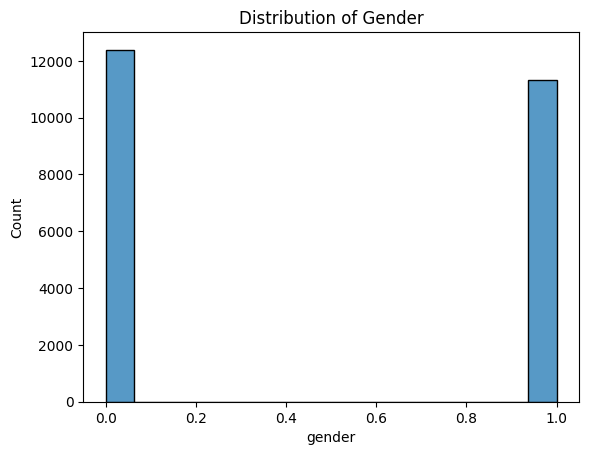

In [ ]:
# Plotting the distribution of 'gender'
sns.histplot(data.gender).set(title="Distribution of Gender")

#Data Preprocessing

In [ ]:
# Create a copy of the original DataFrame
data_shuffled = data.copy()

# Shuffle the copied DataFrame
data_shuffled = data_shuffled.sample(frac=1).reset_index(drop=True)

print("First 5 entries of the shuffled DataFrame:")
print(data_shuffled.head())


First 5 entries of the shuffled DataFrame:
                                               image  age  gender
0  /content/utkface-new/utkface_aligned_cropped/U...   10       0
1  /content/utkface-new/utkface_aligned_cropped/U...   26       1
2  /content/utkface-new/utkface_aligned_cropped/U...   80       0
3  /content/utkface-new/utkface_aligned_cropped/U...   95       1
4  /content/utkface-new/utkface_aligned_cropped/U...   28       1


In [ ]:
print("Null values in the shuffled DataFrame:")
print(data_shuffled.isnull().sum())


Null values in the shuffled DataFrame:
image     0
age       0
gender    0
dtype: int64


# Data Analysis
Analyze the 'age' and 'gender' columns in the `data_shuffled` DataFrame to identify and visualize outliers or inconsistencies, specifically by examining the distribution of age, verifying gender values, and checking for unusual age-gender combinations.

## Analyze Age Distribution for Outliers




Descriptive statistics for 'age' column:
count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


[Text(0.5, 1.0, 'Box Plot of Age Distribution with Outliers')]

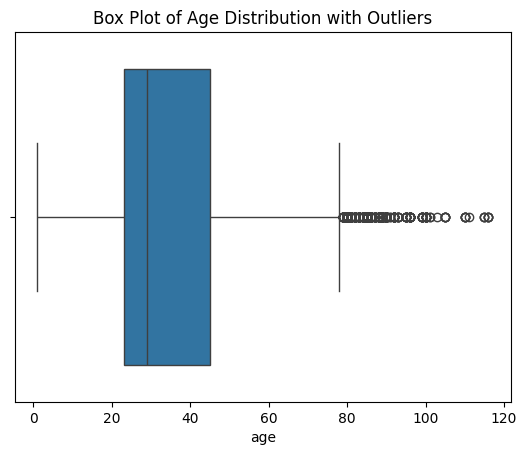

In [ ]:
print("Descriptive statistics for 'age' column:")
print(data_shuffled['age'].describe())

# Create a box plot of the 'age' column to visualize outliers
sns.boxplot(x=data_shuffled['age']).set(title="Box Plot of Age Distribution with Outliers")

## Check for Inconsistent Gender Values





To verify that the 'gender' column only contains binary values (0 or 1).

In [ ]:
print("Unique values in 'gender' column:")
print(data_shuffled['gender'].unique())

print("\nValue counts for 'gender' column:")
print(data_shuffled['gender'].value_counts())

Unique values in 'gender' column:
[0 1]

Value counts for 'gender' column:
gender
0    12391
1    11317
Name: count, dtype: int64


## Identify Extreme Age-Gender Combinations

Investigate if there are any data points with age and gender combinations that seem highly improbable or inconsistent (e.g., extreme ages associated with specific gender representations that could indicate data errors).


In [ ]:
print("Descriptive statistics for 'age' grouped by 'gender':")
print(data_shuffled.groupby('gender')['age'].describe())

Descriptive statistics for 'age' grouped by 'gender':
          count       mean        std  min   25%   50%   75%    max
gender                                                             
0       12391.0  35.695666  19.705223  1.0  25.0  34.0  50.0  110.0
1       11317.0  30.684280  19.753650  1.0  21.0  26.0  37.0  116.0


To visually compare the age distributions for each gender and identify potential outliers, create side-by-side box plots of the 'age' column, separated by 'gender'.



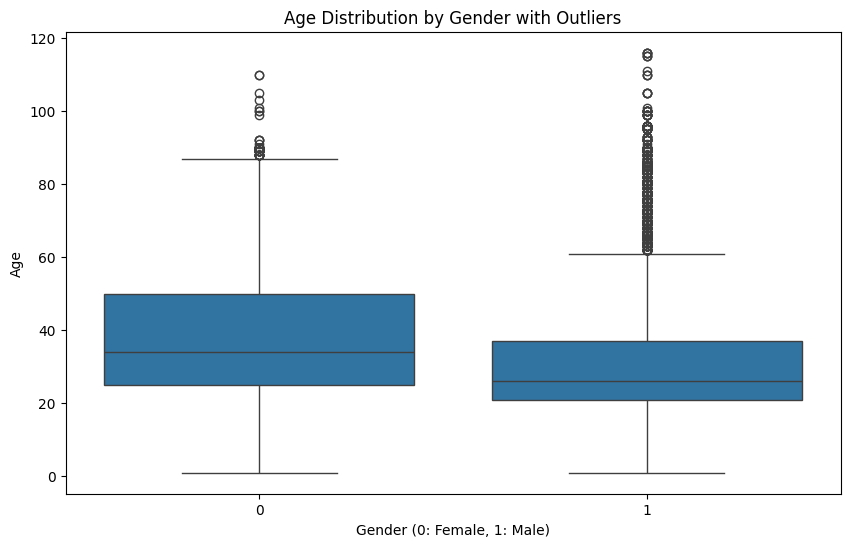

In [ ]:


plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='age', data=data_shuffled)
plt.title('Age Distribution by Gender with Outliers')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Age')
plt.show()

## Summary:

The analysis successfully identified and visualized potential outliers and inconsistencies in the 'age' and 'gender' columns.
*   **Age Distribution:** The 'age' column shows a wide range (1 to 116 years) with a right-skewed distribution, and a maximum age of 116 indicating potential outliers at the upper end.
*   **Gender Values:** The 'gender' column is consistent, containing only the expected binary values (0 and 1).
*   **Age-Gender Combinations:** While both gender groups exhibit a wide age range (up to 110 for gender 0 and 116 for gender 1), no immediately impossible or highly inconsistent age-gender combinations were identified.

### Data Analysis Key Findings
*   The 'age' column in `data_shuffled` has a mean of 33.30 and a median of 29.00, suggesting a right-skewed distribution.
*   A wide age range is observed, from a minimum of 1 year to a maximum of 116 years, with the maximum age potentially indicating outliers.
*   The 'gender' column contains only two unique values: 0 (12,391 occurrences) and 1 (11,317 occurrences), confirming consistency and the absence of unexpected entries.
*   When grouped by gender, the mean age for gender 0 is approximately 35.7 years (range 1-110), and for gender 1 is approximately 30.7 years (range 1-116).
*   No impossible age values (e.g., negative ages) or highly improbable age-gender combinations were found in the dataset, although the upper age limits of 110 and 116 are at the very high end of human lifespan.



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

In [ ]:
image_paths, age_labels, gender_labels = [], [], []
AGE_MAX = 80.0

for item in os.listdir(data_path):
    if item.endswith(".jpg") or item.endswith(".png"):
        parts = item.split('_')
        if len(parts) >= 2:
            try:
                age = int(parts[0])
                gender = int(parts[1])
                if 1 <= age <= AGE_MAX and gender in [0, 1]:
                    image_paths.append(os.path.join(data_path, item))
                    age_labels.append(age)
                    gender_labels.append(gender)
            except ValueError:
                continue

data = pd.DataFrame({'image': image_paths, 'age': age_labels, 'gender': gender_labels})
data['age_norm'] = data['age'] / AGE_MAX
print(f"Total valid images: {len(data)}")

Total valid images: 23168


In [ ]:
# Shuffle
data = data.sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
# Downsample overrepresented ages
max_samples = int(data['age'].value_counts().quantile(0.75))
downsampled = []
for age in data['age'].unique():
    group = data[data['age'] == age]
    downsampled.append(group.sample(n=min(len(group), max_samples), random_state=42))

data_final = pd.concat(downsampled).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"After downsampling: {len(data_final)}")


After downsampling: 16579


[Text(0.5, 1.0, 'Distribution of Age after Downsampling')]

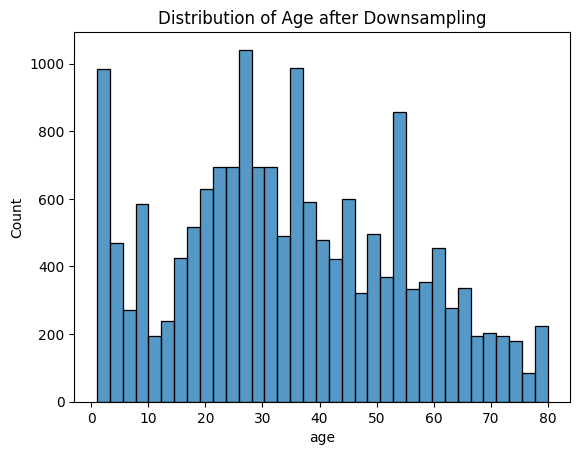

In [ ]:
#DISTRIBUTION after downsampling
sns.histplot(data_final.age).set(title="Distribution of Age after Downsampling")


In [ ]:
# Split — 75% train, 10% val, 15% test
train_df, test_df = train_test_split(data_final, test_size=0.15, random_state=42)
train_df, val_df  = train_test_split(train_df,  test_size=0.12, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 12400 | Val: 1692 | Test: 2487


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def load_and_preprocess(path, age, gender):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, {'age_output': age, 'gender_output': gender}

def augment(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, labels

def make_dataset(df, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df['image'].values,
        df['age'].values.astype(np.float32),
        df['gender'].values.astype(np.float32)
    ))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, augment_data=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

In [ ]:
from tensorflow.keras import regularizers

def build_model():
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    age_x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    age_x = layers.Dropout(0.3)(age_x)
    age_output = layers.Dense(1, activation='relu', name='age_output')(age_x)

    gender_x = layers.Dense(64, activation='relu')(x)
    gender_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gender_x)

    return Model(inputs, [age_output, gender_output]), base

model, base_model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    655,872 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,664 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     32,832 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │         65 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,014,594 (11.50 MB)

 Trainable params: 755,586 (2.88 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [ ]:
model.compile(
    optimizer=Adam(1e-3),
    loss={
        'age_output': 'mae',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={'age_output': 0.02, 'gender_output': 1.0},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy'}
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_age_output_mae', patience=5, restore_best_weights=True, mode='min'),
        ReduceLROnPlateau(monitor='val_age_output_mae', factor=0.5, patience=2, mode='min'),
        ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_age_output_mae', mode='min')
    ]
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - age_output_loss: 10.6258 - age_output_mae: 10.6243 - gender_output_accuracy: 0.8323 - gender_output_loss: 0.3683 - loss: 0.5955 - val_age_output_loss: 10.1797 - val_age_output_mae: 10.1761 - val_gender_output_accuracy: 0.8481 - val_gender_output_loss: 0.3343 - val_loss: 0.5510 - learning_rate: 0.0010
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - age_output_loss: 10.2203 - age_output_mae: 10.2204 - gender_output_accuracy: 0.8487 - gender_output_loss: 0.3319 - loss: 0.5493 - val_age_output_loss: 9.1623 - val_age_output_mae: 9.1561 - val_gender_output_accuracy: 0.8469 - val_gender_output_loss: 0.3559 - val_loss: 0.5508 - learning_rate: 0.0010
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - age_output_loss: 9.9377 - age_output_mae: 9.9385 - gender_output_accuracy: 0.8597 - gender_output_loss: 0.3136 - loss: 0.5241 - val_age_output_loss: 9.7559 - val_age_output_mae: 9.7529 - val_gender_output_accuracy: 0.8534 - val_g

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss={
        'age_output': 'mae',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={'age_output': 0.02, 'gender_output': 1.0},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy'}
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        EarlyStopping(monitor='val_age_output_mae', patience=7, restore_best_weights=True, mode='min'),
        ReduceLROnPlateau(monitor='val_age_output_mae', factor=0.3, patience=3, mode='min'),
        ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_age_output_mae', mode='min')
    ]
)

Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 56s 99ms/step - age_output_loss: 8.5222 - age_output_mae: 8.5197 - gender_output_accuracy: 0.9490 - gender_output_loss: 0.1324 - loss: 0.3086 - val_age_output_loss: 8.3026 - val_age_output_mae: 8.2996 - val_gender_output_accuracy: 0.8617 - val_gender_output_loss: 0.4068 - val_loss: 0.5782 - learning_rate: 1.0000e-05
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - age_output_loss: 8.3914 - age_output_mae: 8.3902 - gender_output_accuracy: 0.9496 - gender_output_loss: 0.1271 - loss: 0.3007 - val_age_output_loss: 8.3215 - val_age_output_mae: 8.3172 - val_gender_output_accuracy: 0.8670 - val_gender_output_loss: 0.3864 - val_loss: 0.5581 - learning_rate: 1.0000e-05
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - age_output_loss: 8.3053 - age_output_mae: 8.3049 - gender_output_accuracy: 0.9568 - gender_output_loss: 0.1143 - loss: 0.2862 - val_age_output_loss: 8.3030 - val_age_output_mae: 8.2998 - val_gender_output_accuracy: 0.8647 - val_

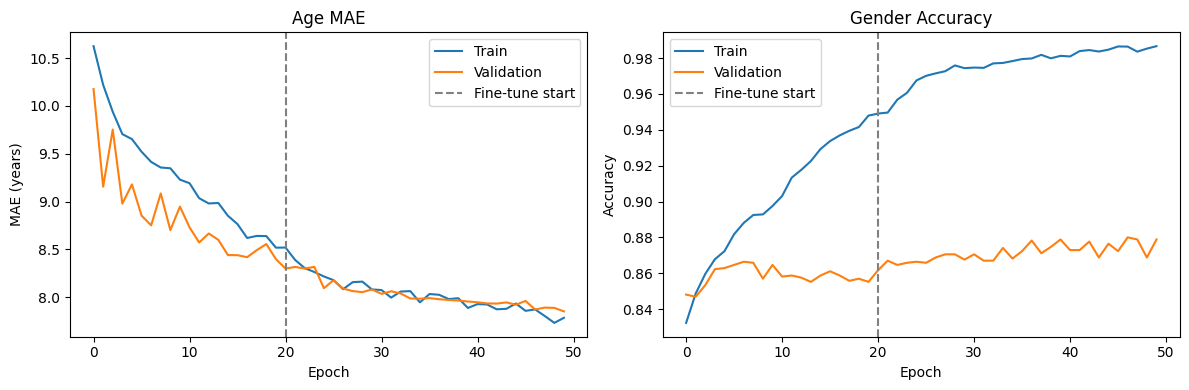

In [ ]:
def plot_history(h1, h2, metric, title, ylabel):
    full_train = h1.history[metric] + h2.history[metric]
    full_val   = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    split_pt   = len(h1.history[metric])

    plt.plot(full_train, label='Train')
    plt.plot(full_val,   label='Validation')
    plt.axvline(split_pt, color='gray', linestyle='--', label='Fine-tune start')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.legend()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_history(history1, history2, 'age_output_mae', 'Age MAE', 'MAE (years)')
plt.subplot(1, 2, 2)
plot_history(history1, history2, 'gender_output_accuracy', 'Gender Accuracy', 'Accuracy')
plt.tight_layout(); plt.show()

AGE REGRESSION METRICS
  MAE          : 7.79 years
  RMSE         : 10.66 years
  R²           : 0.7091
  Within ±5yr  : 45.0%
  Within ±10yr : 71.7%

GENDER CLASSIFICATION METRICS
              precision    recall  f1-score   support

        Male       0.89      0.90      0.89      1342
      Female       0.88      0.87      0.87      1145

    accuracy                           0.88      2487
   macro avg       0.88      0.88      0.88      2487
weighted avg       0.88      0.88      0.88      2487



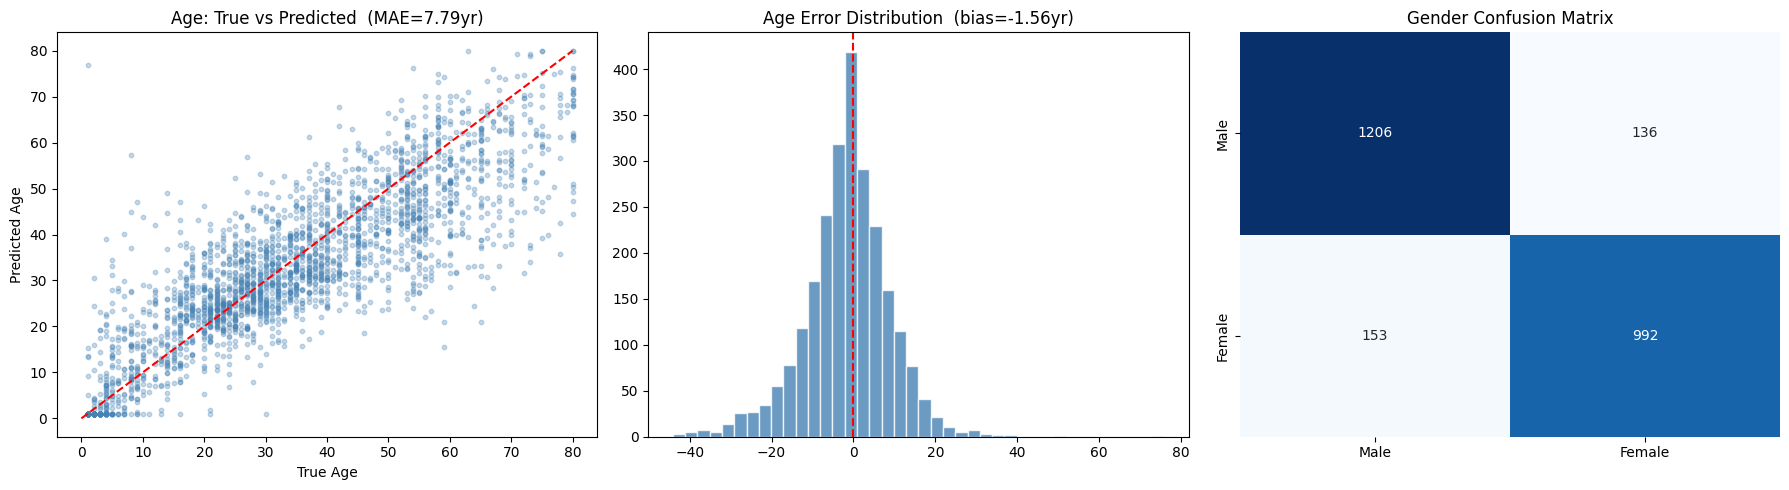

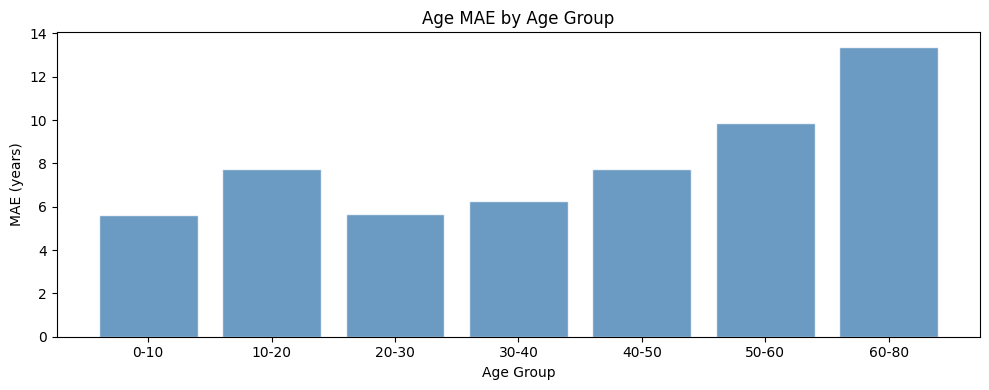

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

model = tf.keras.models.load_model('best_model.keras')

age_true, age_pred_all, gender_true, gender_pred_raw = [], [], [], []

for imgs, labels in test_ds:
    ap, gp = model.predict(imgs, verbose=0)
    age_true.extend(labels['age_output'].numpy())
    age_pred_all.extend(ap.flatten())
    gender_true.extend(labels['gender_output'].numpy())
    gender_pred_raw.extend(gp.flatten())

age_true     = np.array(age_true)
age_pred_all = np.clip(np.array(age_pred_all), 1, 80)
gender_true  = np.array(gender_true).astype(int)
gender_pred  = (np.array(gender_pred_raw) >= 0.5).astype(int)

mae     = mean_absolute_error(age_true, age_pred_all)
rmse    = np.sqrt(mean_squared_error(age_true, age_pred_all))
r2      = r2_score(age_true, age_pred_all)
within5 = np.mean(np.abs(age_true - age_pred_all) <= 5) * 100
within10= np.mean(np.abs(age_true - age_pred_all) <= 10) * 100

print("=" * 45)
print("AGE REGRESSION METRICS")
print("=" * 45)
print(f"  MAE          : {mae:.2f} years")
print(f"  RMSE         : {rmse:.2f} years")
print(f"  R²           : {r2:.4f}")
print(f"  Within ±5yr  : {within5:.1f}%")
print(f"  Within ±10yr : {within10:.1f}%")

print("\n" + "=" * 45)
print("GENDER CLASSIFICATION METRICS")
print("=" * 45)
print(classification_report(gender_true, gender_pred, target_names=['Male', 'Female']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(age_true, age_pred_all, alpha=0.3, s=10, c='steelblue')
axes[0].plot([0, 80], [0, 80], 'r--', lw=1.5)
axes[0].set_xlabel("True Age"); axes[0].set_ylabel("Predicted Age")
axes[0].set_title(f"Age: True vs Predicted  (MAE={mae:.2f}yr)")

errors = age_pred_all - age_true
axes[1].hist(errors, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title(f"Age Error Distribution  (bias={errors.mean():.2f}yr)")

cm = confusion_matrix(gender_true, gender_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=['Male','Female'], yticklabels=['Male','Female'],
            cmap='Blues', cbar=False)
axes[2].set_title("Gender Confusion Matrix")
plt.tight_layout(); plt.show()

fig2, ax = plt.subplots(figsize=(10, 4))
bins = [0,10,20,30,40,50,60,80]
bin_labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-80']
bin_idx = np.digitize(age_true, bins) - 1
group_mae = [mean_absolute_error(age_true[bin_idx==i], age_pred_all[bin_idx==i])
             if (bin_idx==i).sum() > 0 else 0 for i in range(len(bin_labels))]
ax.bar(bin_labels, group_mae, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel("Age Group"); ax.set_ylabel("MAE (years)")
ax.set_title("Age MAE by Age Group")
plt.tight_layout(); plt.show()

In [ ]:
# def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1'):
#     # Model that outputs last conv layer + final predictions
#     grad_model = Model(
#         inputs=model.inputs,
#         outputs=[
#             model.get_layer(last_conv_layer_name).output,
#             model.output
#         ]
#     )
#     with tf.GradientTape() as tape:
#         conv_outputs, predictions = grad_model(img_array)
#         # Use age output as the target for Grad-CAM
#         loss = predictions[0][:, 0]

#     grads      = tape.gradient(loss, conv_outputs)
#     pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
#     conv_out   = conv_outputs[0]
#     heatmap    = conv_out @ pooled[..., tf.newaxis]
#     heatmap    = tf.squeeze(heatmap)
#     heatmap    = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
#     return heatmap.numpy()

# def overlay_gradcam(original_img, heatmap, alpha=0.4):
#     heatmap_resized = np.uint8(255 * heatmap)
#     colormap  = cm.get_cmap('jet')
#     colored   = colormap(
#         np.uint8(255 * heatmap) / 255.0
#     )[:, :, :3]
#     colored   = np.uint8(colored * 255)
#     colored   = Image.fromarray(colored).resize(
#         (original_img.shape[1], original_img.shape[0])
#     )
#     colored   = np.array(colored)
#     overlay   = np.uint8(original_img * (1 - alpha) + colored * alpha)
#     return overlay



In [ ]:
# import gradio as gr
# import matplotlib.cm as cm
# from PIL import Image

# GENDER_LABELS = {0: 'Male', 1: 'Female'}

# def predict(image):
#     # Preprocess
#     img_resized = image.resize((IMG_SIZE, IMG_SIZE))
#     img_array   = np.array(img_resized).astype(np.float32) / 255.0
#     img_input   = np.expand_dims(img_array, axis=0)

#     # Predict
#     age_pred, gender_pred = model.predict(img_input, verbose=0)
#     age    = int(np.round(age_pred[0][0]))
#     gender = GENDER_LABELS[int(gender_pred[0][0] >= 0.5)]
#     confidence = float(gender_pred[0][0]) if gender == 'Female' else 1 - float(gender_pred[0][0])

#     # Grad-CAM
#     heatmap = make_gradcam_heatmap(img_input, model)
#     gradcam = overlay_gradcam(np.array(img_resized), heatmap)

#     result_text = f"Predicted Age: {age} years\nGender: {gender} ({confidence*100:.1f}% confidence)"
#     return result_text, Image.fromarray(gradcam)

# demo = gr.Interface(
#     fn=predict,
#     inputs=gr.Image(type='pil', label="Upload a face photo"),
#     outputs=[
#         gr.Textbox(label="Prediction"),
#         gr.Image(label="Grad-CAM Heatmap")
#     ],
#     title="Age & Gender Predictor",
#     description="Upload a face image to predict age and gender. The heatmap shows which facial regions the model focused on.",
#     examples=[]  # optionally add example images here
# )

# demo.launch(share=True)  # share=True gives you a public URL from Colab